In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
from sklearn.datasets import fetch_california_housing

In [5]:
fch=fetch_california_housing()

In [7]:
fch

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [9]:
df=pd.DataFrame(fch.data,columns=fch.feature_names)

In [11]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [15]:
df['Price']=fch.target

In [17]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


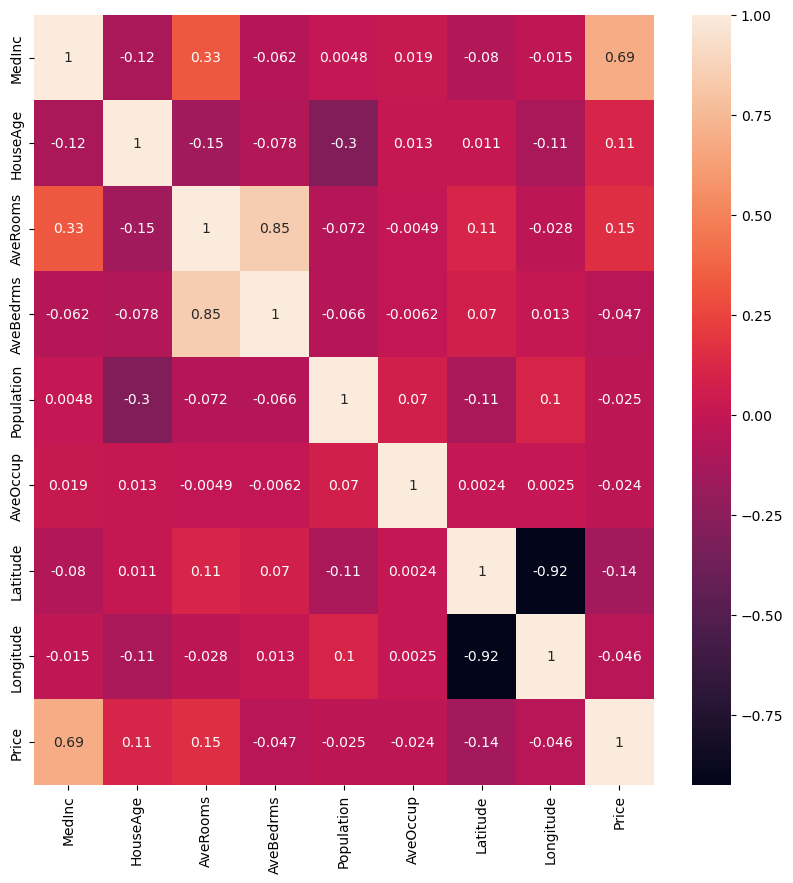

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [29]:
x=df.drop('Price',axis=1)
y=df['Price']

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=10)

In [43]:
x_train.shape,x_test.shape

((13828, 8), (6812, 8))

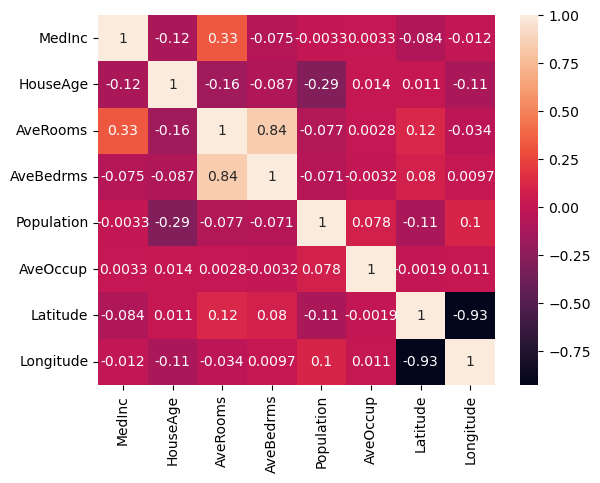

In [115]:
sns.heatmap(x_train.corr(),annot=True)
plt.show()

In [123]:
corr=x_train.corr().abs()

upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))

x=[col for col in upper.columns if any(upper[col]>0.7)]

x

['AveBedrms', 'Longitude']

In [47]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [59]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

In [61]:
model.coef_


array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [101]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False).reset_index(drop=True)

print(coef_df)

      Feature  Coefficient  Abs_Coefficient
0    Latitude    -0.930180         0.930180
1   Longitude    -0.895055         0.895055
2      MedInc     0.828723         0.828723
3   AveBedrms     0.328591         0.328591
4    AveRooms    -0.270688         0.270688
5    HouseAge     0.123116         0.123116
6    AveOccup    -0.028101         0.028101
7  Population     0.002136         0.002136


In [109]:
## PERFORMANCE MATRICES
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=model.predict(x_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f"mean_squared_error:{mse}")
print(f"mean_absolute_error:{mae}")
print(f"R^2 Score:{score}")

mean_squared_error:0.5522332399363618
mean_absolute_error:0.537105694300796
R^2 Score:0.593595852643664


In [111]:
y_pred

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])

In [113]:
df.to_csv("California_housing.csv")